In [2]:
!pip install pandas numpy matplotlib seaborn plotly

In [4]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px

### Uploading the `owid-covid-data.csv` file

To upload the file, run the cell below. A file picker will appear, allowing you to select the `owid-covid-data.csv` file from your local machine. Once uploaded, the file will be accessible in the Colab environment, usually in the `/content/` directory.

In [6]:
from google.colab import files

# Upload the file from your local system
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

# After uploading, you should be able to read it directly
# If the file is uploaded, it will be in the current working directory, not in a 'data' subfolder.
# You might need to adjust the path in the next cell to just 'owid-covid-data.csv'

Saving owid-covid-data.csv to owid-covid-data.csv
User uploaded file "owid-covid-data.csv" with length 91886922 bytes


In [11]:
df = pd.read_csv("owid-covid-data.csv")
print("Columns in the DataFrame:")
print(df.columns.tolist())

print("\nDataFrame Info:")
df.info()

Columns in the DataFrame:
['iso_code', 'continent', 'location', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'reproduction_rate', 'icu_patients', 'icu_patients_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'tests_units', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations_smoothed', 'total_vaccinations_per_hundred', 'people_vaccinated_per_hundred', 'people_fully_vaccin

In [12]:
df.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
0,AFG,Asia,Afghanistan,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
1,AFG,Asia,Afghanistan,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
2,AFG,Asia,Afghanistan,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
3,AFG,Asia,Afghanistan,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN
4,AFG,Asia,Afghanistan,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,NaN,37.746,0.5,64.83,0.511,41128772.0,NaN,NaN,NaN,NaN


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 350085 entries, 0 to 350084
Data columns (total 67 columns):
 #   Column                                      Non-Null Count   Dtype  
---  ------                                      --------------   -----  
 0   iso_code                                    350085 non-null  object 
 1   continent                                   333420 non-null  object 
 2   location                                    350085 non-null  object 
 3   date                                        350085 non-null  object 
 4   total_cases                                 312088 non-null  float64
 5   new_cases                                   340457 non-null  float64
 6   new_cases_smoothed                          339198 non-null  float64
 7   total_deaths                                290501 non-null  float64
 8   new_deaths                                  340511 non-null  float64
 9   new_deaths_smoothed                         339281 non-null  float64
 

In [15]:
df.shape

(350085, 67)

In [25]:
sl = df[df['location'] == 'Sri Lanka']

In [26]:
sl.head()

,iso_code,continent,location,date,total_cases,new_cases,new_cases_smoothed,total_deaths,new_deaths,new_deaths_smoothed,...,male_smokers,handwashing_facilities,hospital_beds_per_thousand,life_expectancy,human_development_index,population,excess_mortality_cumulative_absolute,excess_mortality_cumulative,excess_mortality,excess_mortality_cumulative_per_million
296272,LKA,Asia,Sri Lanka,2020-01-03,NaN,0.0,NaN,NaN,0.0,NaN,...,27.0,NaN,3.6,76.98,0.782,21832150.0,NaN,NaN,NaN,NaN
296273,LKA,Asia,Sri Lanka,2020-01-04,NaN,0.0,NaN,NaN,0.0,NaN,...,27.0,NaN,3.6,76.98,0.782,21832150.0,NaN,NaN,NaN,NaN
296274,LKA,Asia,Sri Lanka,2020-01-05,NaN,0.0,NaN,NaN,0.0,NaN,...,27.0,NaN,3.6,76.98,0.782,21832150.0,NaN,NaN,NaN,NaN
296275,LKA,Asia,Sri Lanka,2020-01-06,NaN,0.0,NaN,NaN,0.0,NaN,...,27.0,NaN,3.6,76.98,0.782,21832150.0,NaN,NaN,NaN,NaN
296276,LKA,Asia,Sri Lanka,2020-01-07,NaN,0.0,NaN,NaN,0.0,NaN,...,27.0,NaN,3.6,76.98,0.782,21832150.0,NaN,NaN,NaN,NaN


In [31]:
sl = sl[['date',
         'total_cases',
         'new_cases',
         'total_deaths',
         'new_deaths',
         'people_vaccinated']]

In [33]:
sl['date'] = pd.to_datetime(sl['date'])

In [34]:
sl.fillna(0, inplace=True)

In [35]:
sl.isnull().sum()

,0
date,0
total_cases,0
new_cases,0
total_deaths,0
new_deaths,0
people_vaccinated,0


In [36]:
sl.describe()

,date,total_cases,new_cases,total_deaths,new_deaths,people_vaccinated
count,1385,1385.000000,1385.000000,1385.000000,1385.000000,1.385000e+03
mean,2021-11-25 00:00:00,393018.200722,485.632491,9401.245487,12.193502,2.814707e+06
min,2020-01-03 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000e+00
25%,2020-12-14 00:00:00,33478.000000,4.000000,154.000000,0.000000,0.000000e+00
50%,2021-11-25 00:00:00,560345.000000,22.000000,14232.000000,1.000000,0.000000e+00
75%,2022-11-06 00:00:00,671328.000000,594.000000,16782.000000,7.000000,7.295620e+05
max,2023-10-18 00:00:00,672593.000000,9962.000000,16882.000000,243.000000,1.714376e+07
std,NaN,295503.571695,972.090169,7753.939154,32.087265,5.804609e+06


In [37]:
print(sl['total_cases'].max())

672593.0


In [38]:
print(sl['total_deaths'].max())

16882.0


In [39]:
print(sl['people_vaccinated'].max())

17143761.0


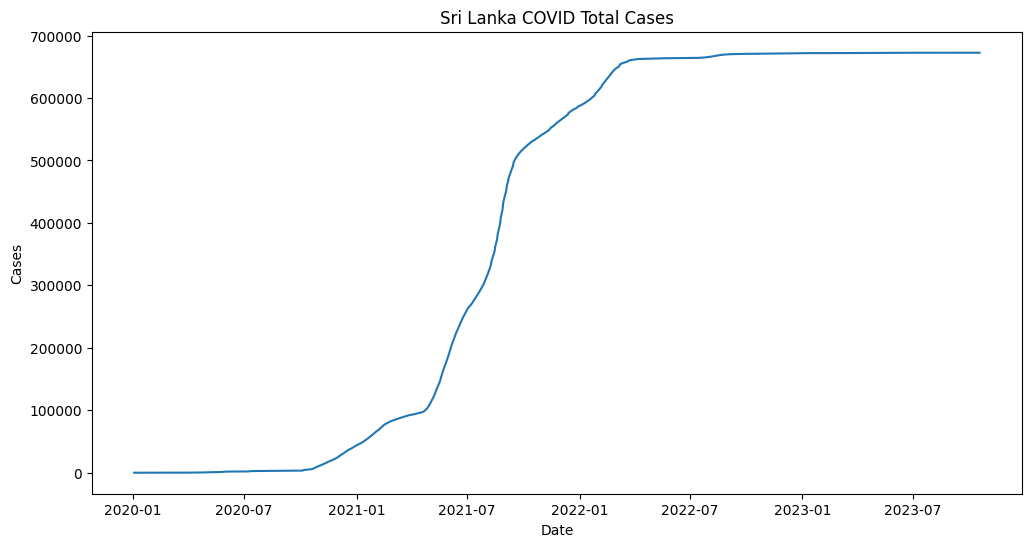

In [40]:
plt.figure(figsize=(12,6))

plt.plot(sl['date'],
         sl['total_cases'])

plt.title("Sri Lanka COVID Total Cases")
plt.xlabel("Date")
plt.ylabel("Cases")

plt.show()

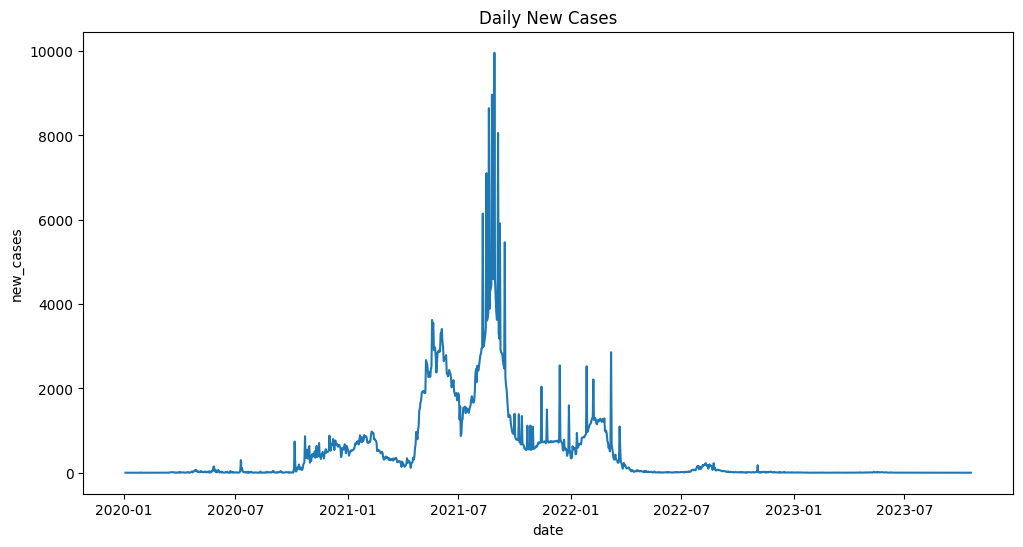

In [41]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x='date',
    y='new_cases',
    data=sl
)

plt.title("Daily New Cases")
plt.show()

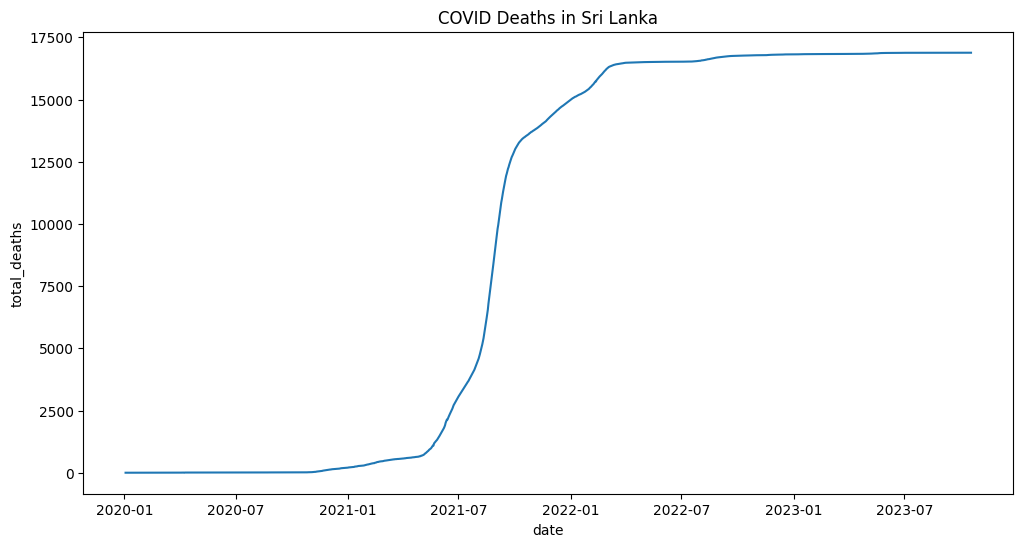

In [42]:
plt.figure(figsize=(12,6))

sns.lineplot(
    x='date',
    y='total_deaths',
    data=sl
)

plt.title("COVID Deaths in Sri Lanka")
plt.show()

In [43]:
fig = px.line(
    sl,
    x='date',
    y='total_cases',
    title='COVID Cases Dashboard'
)

fig.show()

In [45]:
latest = df.groupby('location').last()

top10 = latest.sort_values(
    by='total_cases',
    ascending=False
).head(10)

In [46]:
top10[['total_cases']]

,total_cases
location,
World,771407061.0
High income,425988398.0
Asia,300681974.0
Europe,249783754.0
Upper middle income,244463792.0
European Union,184210531.0
North America,124492151.0
United States,103436829.0
China,99315684.0


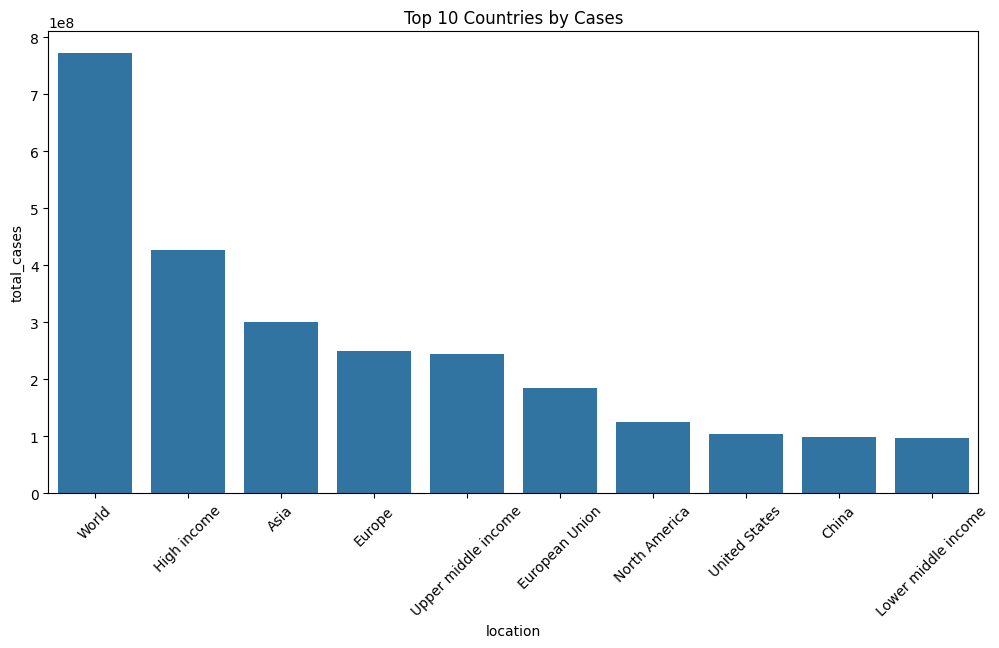

In [47]:
plt.figure(figsize=(12,6))

sns.barplot(
    x=top10.index,
    y=top10['total_cases']
)

plt.xticks(rotation=45)

plt.title("Top 10 Countries by Cases")

plt.show()

In [50]:
!ls

owid-covid-data.csv  sample_data
